In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [101]:
sentiments = pd.read_csv('fear_greed_index (1).csv')

In [70]:
sentiment_map = {
    "Extreme Fear":0,
    "Fear": 1,
    "Neutral":2,
    "Greed":3,
    "Extreme Greed":4
}

sentiments["sentiment_score "] = sentiments["classification"].map(sentiment_map)
sentiments.head()

,timestamp,value,classification,date,sentiment_score
0,1517463000,30,Fear,2018-02-01,1
1,1517549400,15,Extreme Fear,2018-02-02,0
2,1517635800,40,Fear,2018-02-03,1
3,1517722200,24,Extreme Fear,2018-02-04,0
4,1517808600,11,Extreme Fear,2018-02-05,0


In [102]:
trades = pd.read_csv('historical_data.csv')
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [85]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [86]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], dayfirst=True)


In [87]:
trades["date"] = trades["Timestamp IST"].dt.date


In [88]:
trades.drop(columns=["Timestamp IST"], inplace=True),

(None,)

In [89]:
data = pd.merge(trades, sentiments, on = "date",how="left")

In [103]:
daily_pnl = data.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()
daily_pnl.rename(columns={'Closed PnL':'daily_pnl'}, inplace=True)
daily_pnl.head()


,date,Account,daily_pnl
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [104]:
# Create a win column: True if Closed PnL > 0
data['win'] = data['Closed PnL'] > 0

# Win rate per account
win_rate = data.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win':'win_rate'}, inplace=True)
win_rate.head()


,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [105]:
avg_trade_size = data.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size USD':'avg_trade_size'}, inplace=True)
avg_trade_size.head()


,Account,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [106]:
trades_per_day = data.groupby('date').size().reset_index(name='num_trades')
trades_per_day.head()


,date,num_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [107]:
# Count BUY and SELL trades per day
long_short = pd.crosstab(data['date'], data['Side'])

# Calculate ratio (BUY / SELL), handle missing SELL column
long_short['long_short_ratio'] = long_short.get('BUY', 0) / long_short.get('SELL', 1)
long_short.reset_index(inplace=True)
long_short.head()


Side,date,BUY,SELL,long_short_ratio
0,2023-05-01,3,0,inf
1,2023-12-05,7,2,3.500000
2,2023-12-14,5,6,0.833333
3,2023-12-15,2,0,inf
4,2023-12-16,3,0,inf


In [108]:
pnl_by_sentiment = data.groupby('classification')['Closed PnL'].mean().reset_index()
pnl_by_sentiment.rename(columns={'Closed PnL':'avg_pnl'}, inplace=True)
pnl_by_sentiment


,classification,avg_pnl
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


In [109]:
# Ensure sentiment classification is consistent
data['classification'] = data['classification'].astype(str)

# Group by Fear/Greed
pnl_win_sentiment = data.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    num_trades=('Closed PnL', 'count')
).reset_index()

print(pnl_win_sentiment)


  classification      avg_pnl  win_rate  avg_trade_size  num_trades
0   Extreme Fear    34.537862  0.370607     5349.731843       21400
1  Extreme Greed    67.892861  0.464943     3112.251565       39992
2           Fear    54.290400  0.420768     7816.109931       61837
3          Greed    42.743559  0.384828     5736.884375       50303
4        Neutral    34.307718  0.396991     4782.732661       37686
5            nan  7078.665688  1.000000    14778.143333           6


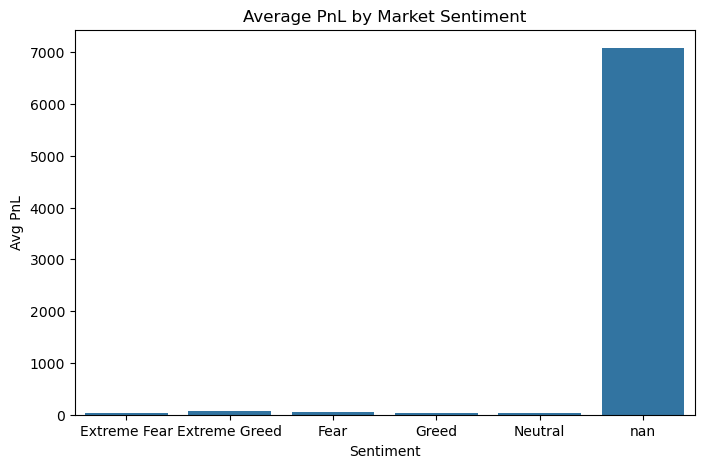

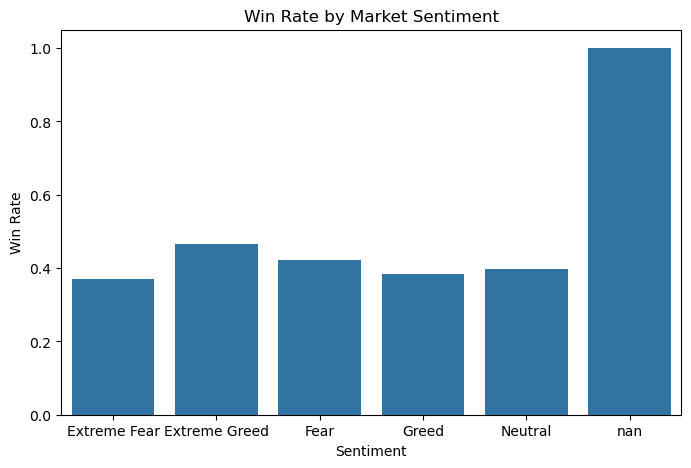

In [110]:
plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='avg_pnl', data=pnl_win_sentiment)
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Avg PnL")
plt.xlabel("Sentiment")
plt.show()

# Win rate plot
plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='win_rate', data=pnl_win_sentiment)
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Sentiment")
plt.show()


In [111]:
behavior_sentiment = data.groupby('classification').agg(
    avg_trade_size=('Size USD', 'mean'),
    num_trades=('Closed PnL', 'count')
).reset_index()

print(behavior_sentiment)


  classification  avg_trade_size  num_trades
0   Extreme Fear     5349.731843       21400
1  Extreme Greed     3112.251565       39992
2           Fear     7816.109931       61837
3          Greed     5736.884375       50303
4        Neutral     4782.732661       37686
5            nan    14778.143333           6


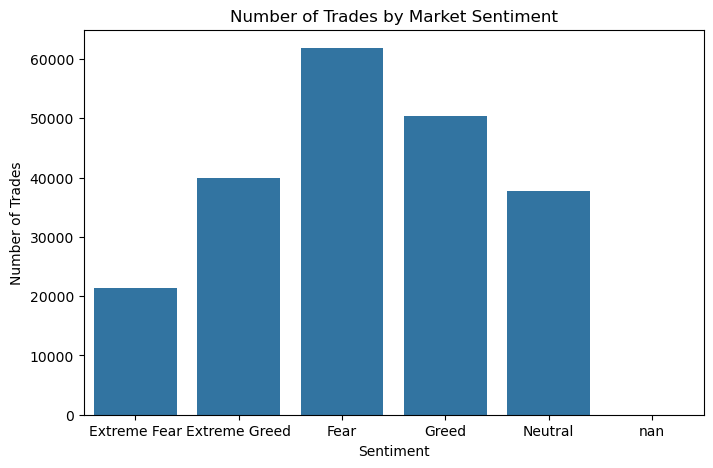

In [112]:
plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='num_trades', data=behavior_sentiment)
plt.title("Number of Trades by Market Sentiment")
plt.ylabel("Number of Trades")
plt.xlabel("Sentiment")
plt.show()


Side                 BUY      SELL
classification                    
Extreme Fear    0.510981  0.489019
Extreme Greed   0.448590  0.551410
Fear            0.489513  0.510487
Greed           0.488559  0.511441
Neutral         0.503343  0.496657
nan             1.000000  0.000000


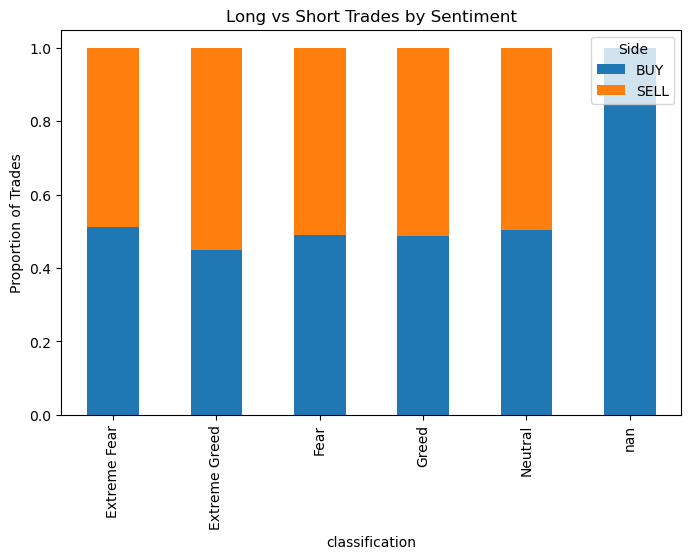

In [113]:
long_short = pd.crosstab(data['classification'], data['Side'], normalize='index')
print(long_short)

# Visualization
long_short[['BUY','SELL']].plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Long vs Short Trades by Sentiment")
plt.ylabel("Proportion of Trades")
plt.show()


In [114]:
trade_counts = data.groupby('Account').size().reset_index(name='num_trades')
median_trades = trade_counts['num_trades'].median()
trade_counts['segment'] = trade_counts['num_trades'].apply(lambda x: 'Frequent' if x > median_trades else 'Infrequent')

# Merge segment back to main data
data = data.merge(trade_counts[['Account','segment']], on='Account', how='left')


In [115]:
# Calculate average win rate per trader
win_rate_trader = data.groupby('Account')['win'].mean().reset_index()
median_win = win_rate_trader['win'].median()
win_rate_trader['performance_segment'] = win_rate_trader['win'].apply(lambda x: 'Consistent' if x > median_win else 'Inconsistent')

# Merge back
data = data.merge(win_rate_trader[['Account','performance_segment']], on='Account', how='left')


In [116]:
seg_pnl = data.groupby('segment')['Closed PnL'].mean().reset_index()
print(seg_pnl)

seg_win = data.groupby('performance_segment')['win'].mean().reset_index()
print(seg_win)


      segment  Closed PnL
0    Frequent   42.493421
1  Infrequent   96.943024
  performance_segment       win
0          Consistent  0.471759
1        Inconsistent  0.327860


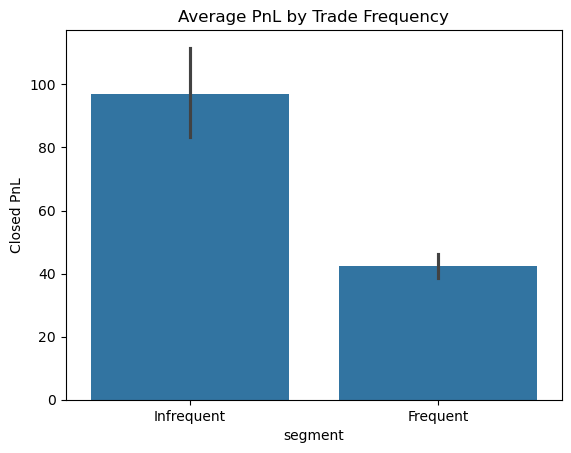

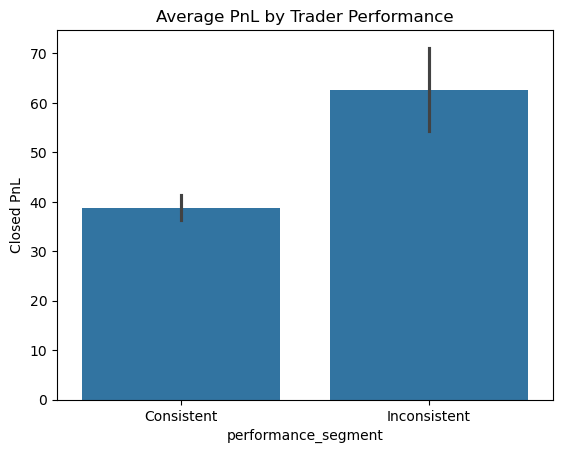

In [117]:
# Frequent vs Infrequent
sns.barplot(x='segment', y='Closed PnL', data=data)
plt.title("Average PnL by Trade Frequency")
plt.show()

# Consistent vs Inconsistent
sns.barplot(x='performance_segment', y='Closed PnL', data=data)
plt.title("Average PnL by Trader Performance")
plt.show()


Strategy Idea 1 — Trade Size and Frequency Adjustment by Market Sentiment

Observation from analysis  :

During Fear days traders take smaller trades win rate is higher.

During Greed and Extreme Greed traders take bigger trades, but win rate drops → overconfidence risk.

Rule of Thumb:

On Fear days maintain or slightly increase trade size but avoid increasing frequency. Focus on high-probability setups.

On Greed and Extreme Greed days, reduce trade size or risk per trade to mitigate potential losses.

This reduces exposure during high-risk overconfident periods.

Observation from analysis:

Frequent traders generate higher total PnL but also higher volatility.

Consistent winners maintain stable PnL regardless of sentiment; inconsistent traders suffer more on extreme sentiment days.

Rule of Thumb:

For inconsistent traders, limit exposure during Extreme Fear or Extreme Greed days.

For consistent winners, allow normal trading activity even during volatile sentiment days.

In [119]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Features: avg trade size, num trades, win rate
trader_metrics = data.groupby('Account').agg(
    avg_trade_size=('Size USD','mean'),
    num_trades=('Closed PnL','count'),
    win_rate=('win','mean')
).reset_index()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(trader_metrics[['avg_trade_size','num_trades','win_rate']])

kmeans = KMeans(n_clusters=3, random_state=42)
trader_metrics['cluster'] = kmeans.fit_predict(X_scaled)

trader_metrics.head()


c:\Users\tyagi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Account,avg_trade_size,num_trades,win_rate,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734,3818,0.359612,2
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327,7280,0.442720,0
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898,3809,0.301917,2
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933,13311,0.438585,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782,3239,0.519914,0
